In [18]:
import os #to work on folders and files and path

DATA_PATH = r"C:\Users\ANANTHU S P\OneDrive\Documents\projects\MHC\AUDIO DATA"

count = 0

for root, dirs, files in os.walk(DATA_PATH):
    for file in files:
        if file.endswith(".wav"):#chechks whether the file is audio or not
            count += 1

print("Total Audio Files:", count)

Total Audio Files: 2880


In [19]:
sample_file = None

for root, dirs, files in os.walk(DATA_PATH):
    for file in files:
        if file.endswith(".wav"):
            sample_file = os.path.join(root, file)
            break
    if sample_file:
        break

In [20]:
import librosa #library for audio processing #read and helps to extract the MFCC features

audio, sr = librosa.load(sample_file)#opens one file
print(audio[:10]) # audio means it is converted to numbers numbers 

print("Audio Length:", len(audio))
print("Sample Rate:", sr) #how many sound measurements are taken every second like frames in video

[ 5.3765390e-08 -2.1233145e-08 -6.0478342e-09  3.8985988e-08
 -7.6543131e-08  1.1907758e-07 -1.6708444e-07  2.2135782e-07
 -2.8319053e-07  3.5470680e-07]
Audio Length: 72838
Sample Rate: 22050


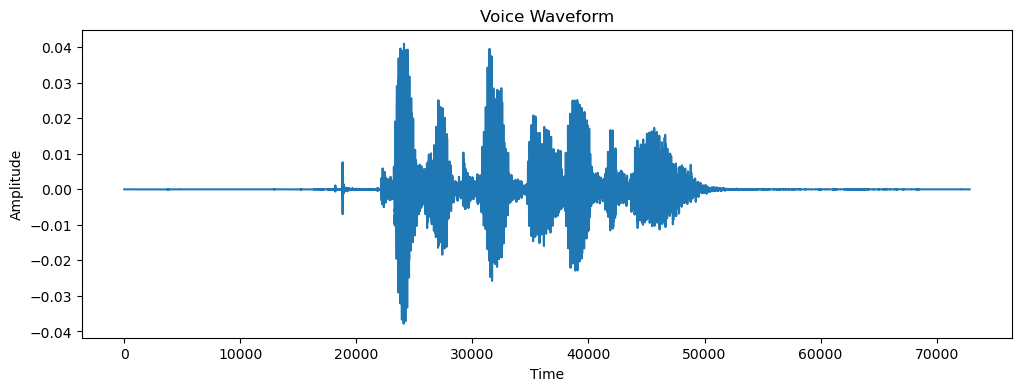

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.plot(audio)
plt.title("Voice Waveform")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.savefig("voice_waveform.png", dpi=300, bbox_inches="tight")
plt.show()

In [22]:
import librosa

mfcc = librosa.feature.mfcc(
    y=audio,
    sr=sr,
    n_mfcc=40 #40 numeric features FPET
)

print("MFCC Shape:", mfcc.shape) #157 time segment splitted by MFCC
#40 features of every 157 later it is avg

MFCC Shape: (40, 143)


In [23]:
import numpy as np

mfcc_mean = np.mean(mfcc.T, axis=0)

print("Feature Shape:", mfcc_mean.shape)
print(mfcc_mean[:10])

Feature Shape: (40,)
[-6.9779260e+02  5.4890041e+01  6.6346514e-01  1.2435786e+01
  7.7339506e+00  5.3075033e-01 -3.2166309e+00 -3.1593945e+00
 -1.0977551e+01 -2.8487110e+00]


In [ ]:
features = []
labels = []

for root, dirs, files in os.walk(DATA_PATH):

    for file in files:

        if file.endswith(".wav"):

            try:

                file_path = os.path.join(root, file)

                audio, sr = librosa.load(file_path)

                mfcc = librosa.feature.mfcc(
                    y=audio,
                    sr=sr,
                    n_mfcc=40
                )

                mfcc_mean = np.mean(mfcc.T, axis=0)

                emotion_code = file.split("-")[2]


                emotion = emotion_map[emotion_code]

                features.append(mfcc_mean)

                labels.append(emotion)

            except:
                pass

print("Total Samples:", len(features))


In [ ]:
import pandas as pd
df = pd.DataFrame(features)

df["emotion"] = labels

print(df.shape)

df.head()

In [ ]:
df["emotion"].value_counts() #how many time each emotion appears

In [ ]:
df.to_csv("emotion_dataset.csv", index=False)

print("Dataset Saved Successfully")

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop("emotion", axis=1)
y = df["emotion"]

X_train, X_test, y_train, y_test = train_test_split( X,y,test_size=0.2,random_state=42,stratify=y)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

print("Model Training Complete")

In [ ]:
from sklearn.metrics import accuracy_score

predictions = model.predict(X_test)

accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", round(accuracy*100, 2), "%")

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, predictions)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model.classes_
)

fig, ax = plt.subplots(figsize=(10,8))
disp.plot(ax=ax)
plt.savefig("mood_trend.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
import joblib

joblib.dump(model, "emotion_model.pkl")

print("Model Saved Successfully")

In [ ]:
#prediction

import joblib
import librosa
import numpy as np

model = joblib.load("emotion_model.pkl")

def extract_features(file_path):
    audio, sr = librosa.load(file_path)

    mfcc = librosa.feature.mfcc(
        y=audio,
        sr=sr,
        n_mfcc=40
    )

    return np.mean(mfcc.T, axis=0)

test_file = r"C:\Users\ANANTHU S P\OneDrive\Documents\projects\MHC\AUDIO DATA\Actor_02\03-01-02-01-02-01-02.wav"

features = extract_features(test_file)
features = features.reshape(1, -1)

prediction = model.predict(features)

print("Predicted Emotion:", prediction[0])

In [ ]:
recommendations = {
    "happy":"Keep up the positive energy!",
    "sad":"Take a short walk and listen to music.",
    "angry":"Practice deep breathing exercises.",
    "fearful":"Try mindfulness activities.",
    "calm":"Maintain your healthy routine.",
    "neutral":"Have a productive day.",
    "disgust":"Take a break and engage in a positive activity.",
    "surprised":"Reflect on what caused the feeling."
}

emotion = prediction[0]

print("Emotion:", emotion)
print("Recommendation:", recommendations[emotion])

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

moods = ['happy','calm','sad','happy','neutral']

score_map = {
    'sad':1,
    'fearful':2,
    'neutral':3,
    'calm':4,
    'happy':5
}

scores = [score_map.get(m,3) for m in moods]

plt.plot(scores, marker='o')
plt.title("Mood Trend")
plt.xlabel("Day")
plt.ylabel("Mood Score")
plt.savefig("confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()